# Fijaciones Múltiples

Análisis en dos niveles:
1. **Multi-fijaciones en los CSVs**: columnas `multi` y `refix` de Damián — fijaciones consecutivas sobre el mismo estímulo.
2. **Fijaciones consecutivas en la misma celda del modelo**: pares de fijaciones contiguas que caen en la misma celda (24×32) y por lo tanto tienen features de grilla idénticas.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sys.path.insert(0, '..')

OUTPUT_DIR   = Path('../hybrid_metadata/output')
FEATURES_DIR = Path('../Features_Damian')

# Features calculadas por celda (24×32) — idénticas si fix_y, fix_x coinciden
FEATS_GRILLA = [
    'saliencia_media', 'saliencia_mediana',
    'similitud_media', 'similitud_mediana',
    'evidencia_visual',
    'competencia_fp_var', 'competencia_fp_media', 'competencia_fp_max',
    'posterior',
    'entropia_prior_saliencia', 'entropia_prior_modelo', 'entropia_posterior',
    'ganancia_informacion',
    'eig_optimo', 'eig_en_fijacion', 'gap_entropia',
    'competencia_ratio_mayor', 'competencia_ratio_segundo_mayor',
    'competencia_ratio', 'competencia_densidad', 'competencia_densidad_norm',
    'distancia_grilla',
]

# Features calculadas a nivel de píxel — pueden diferir aunque la celda sea la misma
FEATS_PIXEL = ['saliencia_pixel', 'similitud_pixel', 'distancia_pixels']

print('Directorios OK')

Directorios OK


---
## 1. Multi-fijaciones en los CSVs

**Definición** (columna `multi`):
- `multi = 0` : fijación aislada — única en una visita consecutiva a ese estímulo.
- `multi = 1, 2, 3…` : índice dentro de una secuencia de fijaciones consecutivas al mismo estímulo (1-based).
- `NaN` : fijación que no cayó sobre ningún estímulo reconocible.

**Definición** (columna `refix`):
- `refix = 0` : primera visita al estímulo en el trial.
- `refix = 1, 2, 3…` : Nª re-visita (no necesariamente consecutiva).
- `NaN` : ídem a `multi`.

In [2]:
# Carga todos los CSVs de output y aplica los mismos filtros que output_csv_to_scanpaths
dfs = []
for csv_path in sorted(OUTPUT_DIR.glob('*.csv')):
    subject = csv_path.stem.replace('_full_metadata', '')
    df = pd.read_csv(csv_path)
    df['subject'] = subject
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

# Filtro idéntico al de output_csv_to_scanpaths (fijaciones que entran al JSON)
fix = raw[
    (raw['type']    == 'fixation') &
    (raw['phase']   == 'vs')       &
    (raw['bad']     == 0)          &
    (raw['inrange'] == True)       &
    (raw['present'] == True)
].copy()

fix['multi'] = pd.to_numeric(fix['multi'], errors='coerce')
fix['refix'] = pd.to_numeric(fix['refix'], errors='coerce')
fix['mss']   = pd.to_numeric(fix['mss'],   errors='coerce').astype('Int64')

print(f'Sujetos: {fix["subject"].nunique()}')
print(f'Fijaciones totales (filtradas): {len(fix):,}')
print(f'Con stm asignado: {fix["stm"].notna().sum():,}')
print(f'Sin stm (multi/refix NaN): {fix["stm"].isna().sum():,}')

Sujetos: 45
Fijaciones totales (filtradas): 65,795
Con stm asignado: 31,232
Sin stm (multi/refix NaN): 34,563


In [3]:
# Solo fijaciones con estímulo asignado (donde multi/refix tienen sentido)
fix_stm = fix[fix['stm'].notna()].copy()

multi_counts = fix_stm['multi'].value_counts().sort_index()
print('Distribución de multi:')
for val, cnt in multi_counts.items():
    pct = 100 * cnt / len(fix_stm)
    print(f'  multi={int(val)}: {cnt:,} ({pct:.1f}%)')

print()
n_multi = fix_stm[fix_stm['multi'] >= 1].shape[0]
pct_multi = 100 * n_multi / len(fix_stm)
print(f'Fijaciones que son parte de un grupo multi (multi>=1): {n_multi:,} ({pct_multi:.1f}%)')

print()
refix_counts = fix_stm['refix'].value_counts().sort_index()
print('Distribución de refix (primeras 6):')
for val, cnt in list(refix_counts.items())[:6]:
    pct = 100 * cnt / len(fix_stm)
    print(f'  refix={int(val)}: {cnt:,} ({pct:.1f}%)')

Distribución de multi:
  multi=0: 17,515 (56.1%)
  multi=1: 5,388 (17.3%)
  multi=2: 6,921 (22.2%)
  multi=3: 1,008 (3.2%)
  multi=4: 260 (0.8%)
  multi=5: 82 (0.3%)
  multi=6: 31 (0.1%)
  multi=7: 14 (0.0%)
  multi=8: 3 (0.0%)
  multi=9: 1 (0.0%)
  multi=10: 1 (0.0%)

Fijaciones que son parte de un grupo multi (multi>=1): 13,709 (43.9%)

Distribución de refix (primeras 6):
  refix=0: 19,939 (63.8%)
  refix=1: 4,534 (14.5%)
  refix=2: 5,656 (18.1%)
  refix=3: 905 (2.9%)
  refix=4: 151 (0.5%)
  refix=5: 31 (0.1%)


/var/folders/8f/d2fjq2v97mj17hpklrr_c6yw0000gn/T/ipykernel_41006/3151439614.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mss_multi = fix_stm.groupby('mss').apply(


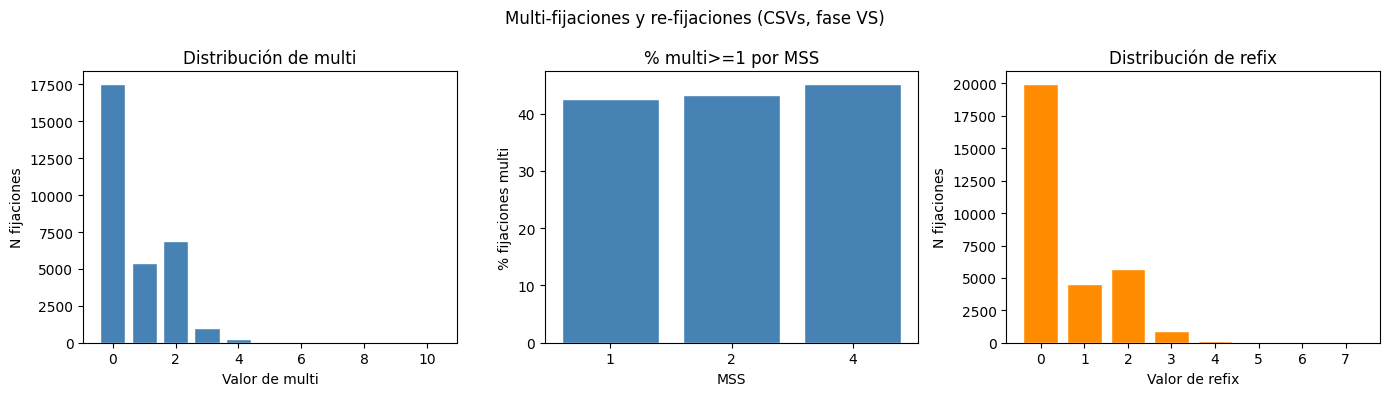

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: distribución de multi
ax = axes[0]
vals = fix_stm['multi'].value_counts().sort_index()
ax.bar(vals.index.astype(int), vals.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Valor de multi')
ax.set_ylabel('N fijaciones')
ax.set_title('Distribución de multi')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 2: % multi>=1 por MSS
ax = axes[1]
mss_multi = fix_stm.groupby('mss').apply(
    lambda g: 100 * (g['multi'] >= 1).sum() / len(g)
).reset_index(name='pct_multi')
ax.bar(mss_multi['mss'].astype(str), mss_multi['pct_multi'], color='steelblue', edgecolor='white')
ax.set_xlabel('MSS')
ax.set_ylabel('% fijaciones multi')
ax.set_title('% multi>=1 por MSS')

# Panel 3: distribución de refix
ax = axes[2]
vals_r = fix_stm['refix'].value_counts().sort_index()
ax.bar(vals_r.index.astype(int), vals_r.values, color='darkorange', edgecolor='white')
ax.set_xlabel('Valor de refix')
ax.set_ylabel('N fijaciones')
ax.set_title('Distribución de refix')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Multi-fijaciones y re-fijaciones (CSVs, fase VS)', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# % multi>=1 por sujeto
subj_multi = fix_stm.groupby('subject').apply(
    lambda g: pd.Series({
        'n_fix': len(g),
        'n_multi': (g['multi'] >= 1).sum(),
        'pct_multi': 100 * (g['multi'] >= 1).sum() / len(g),
        'n_refix': (g['refix'] >= 1).sum(),
        'pct_refix': 100 * (g['refix'] >= 1).sum() / len(g),
    })
).reset_index()

print(subj_multi.to_string(index=False, float_format='%.1f'))

subject  n_fix  n_multi  pct_multi  n_refix  pct_refix
 117969  655.0    207.0       31.6    143.0       21.8
 123082  656.0    261.0       39.8    202.0       30.8
 159640  258.0     82.0       31.8     48.0       18.6
 179678  539.0    201.0       37.3    199.0       36.9
 200877  733.0    251.0       34.2    244.0       33.3
 244108  677.0    238.0       35.2    233.0       34.4
 244389  513.0    167.0       32.6    152.0       29.6
 248301  616.0    257.0       41.7    164.0       26.6
 286470  569.0    214.0       37.6    175.0       30.8
 305138  785.0    489.0       62.3    177.0       22.5
 370500  486.0    138.0       28.4    148.0       30.5
 373490 1100.0    586.0       53.3    568.0       51.6
 389622  700.0    305.0       43.6    268.0       38.3
 400297  560.0    177.0       31.6    242.0       43.2
 419760  650.0    267.0       41.1    164.0       25.2
 501896  443.0    156.0       35.2     95.0       21.4
 533569  508.0    132.0       26.0    157.0       30.9
 573661  2

/var/folders/8f/d2fjq2v97mj17hpklrr_c6yw0000gn/T/ipykernel_41006/2082683823.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subj_multi = fix_stm.groupby('subject').apply(


---
## 2. Fijaciones consecutivas en la misma celda del modelo

Dentro de las `features.json`, `fix_y` y `fix_x` son coordenadas de **grilla** (24×32).  
Si dos fijaciones consecutivas caen en la misma celda, **todas las features de grilla son idénticas** — son el mismo valor de entrada para el modelo TRF.

Las features de **píxel** (`saliencia_pixel`, `similitud_pixel`, `distancia_pixels`) se calculan a mayor resolución y en principio podrían diferir, pero también se derivan de la posición en grilla, por lo que se verificará empíricamente.

In [6]:
# Carga todos los features.json en un DataFrame plano
records = []
for feat_path in sorted(FEATURES_DIR.glob('*/*/features.json')):
    imagen  = feat_path.parts[-3]
    sujeto  = feat_path.parts[-2]
    with open(feat_path) as f:
        data = json.load(f)
    for fix in data.get('fijaciones', []):
        row = {'imagen': imagen, 'sujeto': sujeto}
        row.update(fix)
        records.append(row)

df = pd.DataFrame(records)
print(f'Total fijaciones cargadas: {len(df):,}')
print(f'Imágenes únicas: {df["imagen"].nunique()}')
print(f'Sujetos únicos:  {df["sujeto"].nunique()}')

Total fijaciones cargadas: 61,252
Imágenes únicas: 102
Sujetos únicos:  45


In [14]:
df

,imagen,sujeto,fixation,fix_y,fix_x,saliencia_media,saliencia_mediana,saliencia_pixel,similitud_media,similitud_mediana,...,distancia_grilla,distancia_pixels,competencia_ratio_mayor,competencia_ratio_segundo_mayor,competencia_ratio,competencia_densidad,competencia_densidad_norm,prev_fix_y,prev_fix_x,misma_celda
0,cmp_africansavanna_003_wildanimals_003,117969,0,14,9,0.374502,0.380392,0.000000,0.001214,0.000000,...,12.041595,385.331027,0.246307,0.240675,0.977135,2,0.002604,NaN,NaN,False
1,cmp_africansavanna_003_wildanimals_003,117969,1,5,12,0.026225,0.027451,0.007843,0.007426,0.007843,...,14.035669,449.141403,0.218843,0.214153,0.978570,2,0.002604,14.0,9.0,False
2,cmp_africansavanna_003_wildanimals_003,117969,2,3,12,0.178167,0.156863,0.000000,0.187726,0.176471,...,12.000000,384.000000,0.199432,0.195363,0.979596,2,0.002604,5.0,12.0,False
3,cmp_africansavanna_003_wildanimals_003,117969,3,5,13,0.014706,0.015686,0.015686,0.003332,0.003922,...,9.055385,289.772324,0.178071,0.174640,0.980733,4,0.005208,3.0,12.0,False
4,cmp_africansavanna_003_wildanimals_003,117969,4,8,14,0.136095,0.127451,0.007843,0.000222,0.000000,...,8.602325,275.274409,0.292498,0.269629,0.921815,1,0.001302,5.0,13.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61247,cmp_yard_007_motorcycle_001,S119,6,14,5,0.011029,0.007843,0.000000,0.013538,0.011765,...,3.162278,101.192885,2.796363,2.650525,0.947847,1,0.001302,8.0,9.0,False
61248,cmp_yard_007_motorcycle_001,S119,7,6,10,0.016667,0.015686,0.015686,0.002087,0.003922,...,15.264338,488.458801,3.937187,3.066192,0.778777,1,0.001302,14.0,5.0,False
61249,cmp_yard_007_motorcycle_001,S119,8,22,3,0.000000,0.000000,0.000000,0.020351,0.015686,...,6.082763,194.648401,3.496831,3.185613,0.911000,1,0.001302,6.0,10.0,False
61250,cmp_yard_007_motorcycle_001,S119,9,10,5,0.032353,0.027451,0.000000,0.198024,0.186275,...,7.071068,226.274170,3.742572,3.725929,0.995553,2,0.002604,22.0,3.0,False


In [7]:
# Para cada sujeto+imagen, detectar pares consecutivos en la misma celda
df = df.sort_values(['sujeto', 'imagen', 'fixation']).reset_index(drop=True)

# Shift dentro de cada grupo para comparar con la fijación anterior
grp = df.groupby(['sujeto', 'imagen'])
df['prev_fix_y'] = grp['fix_y'].shift(1)
df['prev_fix_x'] = grp['fix_x'].shift(1)

# Misma celda que la fijación anterior (excluye la primera fijación de cada trial)
df['misma_celda'] = (
    (df['fix_y'] == df['prev_fix_y']) &
    (df['fix_x'] == df['prev_fix_x']) &
    df['prev_fix_y'].notna()
)

n_total = len(df)
n_misma = df['misma_celda'].sum()
print(f'Total fijaciones:                       {n_total:,}')
print(f'Con misma celda que la anterior:        {n_misma:,} ({100*n_misma/n_total:.1f}%)')
print()
print('Por sujeto:')
for s, g in df.groupby('sujeto'):
    nm = g['misma_celda'].sum()
    print(f'  {s}: {nm}/{len(g)} ({100*nm/len(g):.1f}%)')

Total fijaciones:                       61,252
Con misma celda que la anterior:        2,908 (4.7%)

Por sujeto:
  117969: 16/1185 (1.4%)
  123082: 100/1365 (7.3%)
  159640: 26/945 (2.8%)
  179678: 46/1206 (3.8%)
  200877: 76/1433 (5.3%)
  244108: 31/1285 (2.4%)
  244389: 24/992 (2.4%)
  248301: 60/1098 (5.5%)
  286470: 30/1138 (2.6%)
  305138: 126/1315 (9.6%)
  370500: 7/1094 (0.6%)
  373490: 130/2113 (6.2%)
  389622: 49/1378 (3.6%)
  400297: 32/1416 (2.3%)
  419760: 44/1133 (3.9%)
  501896: 41/1021 (4.0%)
  533569: 19/1184 (1.6%)
  573661: 67/1278 (5.2%)
  576470: 26/1314 (2.0%)
  601753: 57/1500 (3.8%)
  619958: 68/1411 (4.8%)
  629959: 71/1340 (5.3%)
  664304: 37/1023 (3.6%)
  677251: 39/1028 (3.8%)
  712871: 114/1395 (8.2%)
  719396: 8/566 (1.4%)
  848643: 44/1271 (3.5%)
  862513: 71/1589 (4.5%)
  963607: 49/1347 (3.6%)
  S101: 145/2109 (6.9%)
  S102: 153/1801 (8.5%)
  S103: 53/1145 (4.6%)
  S105: 107/1685 (6.4%)
  S106: 127/1864 (6.8%)
  S107: 65/1503 (4.3%)
  S108: 89/1550 (5.7%

In [13]:
df

,imagen,sujeto,fixation,fix_y,fix_x,saliencia_media,saliencia_mediana,saliencia_pixel,similitud_media,similitud_mediana,...,distancia_grilla,distancia_pixels,competencia_ratio_mayor,competencia_ratio_segundo_mayor,competencia_ratio,competencia_densidad,competencia_densidad_norm,prev_fix_y,prev_fix_x,misma_celda
0,cmp_africansavanna_003_wildanimals_003,117969,0,14,9,0.374502,0.380392,0.000000,0.001214,0.000000,...,12.041595,385.331027,0.246307,0.240675,0.977135,2,0.002604,NaN,NaN,False
1,cmp_africansavanna_003_wildanimals_003,117969,1,5,12,0.026225,0.027451,0.007843,0.007426,0.007843,...,14.035669,449.141403,0.218843,0.214153,0.978570,2,0.002604,14.0,9.0,False
2,cmp_africansavanna_003_wildanimals_003,117969,2,3,12,0.178167,0.156863,0.000000,0.187726,0.176471,...,12.000000,384.000000,0.199432,0.195363,0.979596,2,0.002604,5.0,12.0,False
3,cmp_africansavanna_003_wildanimals_003,117969,3,5,13,0.014706,0.015686,0.015686,0.003332,0.003922,...,9.055385,289.772324,0.178071,0.174640,0.980733,4,0.005208,3.0,12.0,False
4,cmp_africansavanna_003_wildanimals_003,117969,4,8,14,0.136095,0.127451,0.007843,0.000222,0.000000,...,8.602325,275.274409,0.292498,0.269629,0.921815,1,0.001302,5.0,13.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61247,cmp_yard_007_motorcycle_001,S119,6,14,5,0.011029,0.007843,0.000000,0.013538,0.011765,...,3.162278,101.192885,2.796363,2.650525,0.947847,1,0.001302,8.0,9.0,False
61248,cmp_yard_007_motorcycle_001,S119,7,6,10,0.016667,0.015686,0.015686,0.002087,0.003922,...,15.264338,488.458801,3.937187,3.066192,0.778777,1,0.001302,14.0,5.0,False
61249,cmp_yard_007_motorcycle_001,S119,8,22,3,0.000000,0.000000,0.000000,0.020351,0.015686,...,6.082763,194.648401,3.496831,3.185613,0.911000,1,0.001302,6.0,10.0,False
61250,cmp_yard_007_motorcycle_001,S119,9,10,5,0.032353,0.027451,0.000000,0.198024,0.186275,...,7.071068,226.274170,3.742572,3.725929,0.995553,2,0.002604,22.0,3.0,False


In [8]:
# Verificar que las features de GRILLA son idénticas en pares misma-celda
pares = df[df['misma_celda']].copy()

print('Verificación: ¿features de grilla son idénticas en pares misma celda?')
print(f'(N pares = {len(pares):,})\n')
print(f'{"Feature":<40s}  {"Idénticas":>10}  {"Distintas":>10}  {"% idénticas":>12}')
print('-' * 80)

feats_verificar = FEATS_GRILLA + FEATS_PIXEL
for feat in feats_verificar:
    if feat not in df.columns:
        continue
    # La fijación previa (misma celda)
    prev_vals = df.loc[pares.index - 1, feat].values  # índice contiguo
    curr_vals = pares[feat].values
    # Manejo de NaN: NaN == NaN → True para esta verificación
    with np.errstate(invalid='ignore'):
        iguales = np.array([
            (a == b) or (pd.isna(a) and pd.isna(b))
            for a, b in zip(curr_vals, prev_vals)
        ])
    n_ig = iguales.sum()
    n_dist = len(iguales) - n_ig
    label = '← PÍXEL' if feat in FEATS_PIXEL else ''
    print(f'{feat:<40s}  {n_ig:>10,}  {n_dist:>10,}  {100*n_ig/len(iguales):>11.1f}%  {label}')

Verificación: ¿features de grilla son idénticas en pares misma celda?
(N pares = 2,908)

Feature                                    Idénticas   Distintas   % idénticas
--------------------------------------------------------------------------------
saliencia_media                                2,908           0        100.0%  
saliencia_mediana                              2,908           0        100.0%  
similitud_media                                2,908           0        100.0%  
similitud_mediana                              2,908           0        100.0%  
evidencia_visual                                   0       2,908          0.0%  
competencia_fp_var                                 0       2,908          0.0%  
competencia_fp_media                               0       2,908          0.0%  
competencia_fp_max                                 0       2,908          0.0%  
posterior                                          0       2,908          0.0%  
entropia_prior_salienc

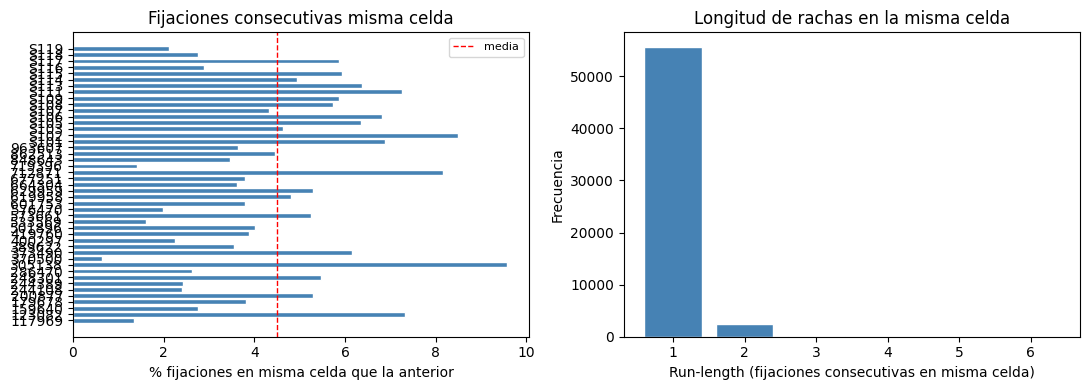

Run-length promedio: 1.05  |  max: 6


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel 1: % misma celda por sujeto
ax = axes[0]
subj_mc = df.groupby('sujeto')['misma_celda'].mean().mul(100).reset_index()
ax.barh(subj_mc['sujeto'], subj_mc['misma_celda'], color='steelblue', edgecolor='white')
ax.set_xlabel('% fijaciones en misma celda que la anterior')
ax.set_title('Fijaciones consecutivas misma celda')
ax.axvline(subj_mc['misma_celda'].mean(), color='red', ls='--', lw=1, label='media')
ax.legend(fontsize=8)

# Panel 2: distribución de run-length de celdas repetidas
ax = axes[1]
run_lens = []
for (s, img), g in df.groupby(['sujeto', 'imagen']):
    run = 1
    for mc in g['misma_celda'].values[1:]:
        if mc:
            run += 1
        else:
            run_lens.append(run)
            run = 1
    run_lens.append(run)

run_series = pd.Series(run_lens)
run_counts = run_series.value_counts().sort_index()
ax.bar(run_counts.index, run_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Run-length (fijaciones consecutivas en misma celda)')
ax.set_ylabel('Frecuencia')
ax.set_title('Longitud de rachas en la misma celda')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()
print(f'Run-length promedio: {run_series.mean():.2f}  |  max: {run_series.max()}')

---
## 3. Relación entre multi (CSV) y misma celda (modelo)

Los dos conceptos **no son equivalentes**:
- `multi` (CSV) = consecutivas sobre el mismo **estímulo** (umbral en píxeles de imagen).
- Misma celda (modelo) = `fix_y`, `fix_x` idénticos en la grilla 24×32.

Una multi-fijación podría caer en celdas distintas si el estímulo abarca más de una celda, y viceversa.

Acá se cruzan ambas fuentes para medir el solapamiento real.

In [10]:
# Construir mapeo sujeto+imagen → lista de multi valores del CSV
# Usamos el orden de fijaciones filtradas (mismo que output_csv_to_scanpaths)
multi_map = {}  # (sujeto_num, imagen) → lista de (multi, refix)
for csv_path in sorted(OUTPUT_DIR.glob('*.csv')):
    subject = csv_path.stem.replace('_full_metadata', '')
    df_csv = pd.read_csv(csv_path)
    df_f = df_csv[
        (df_csv['type']    == 'fixation') &
        (df_csv['phase']   == 'vs')       &
        (df_csv['bad']     == 0)          &
        (df_csv['inrange'] == True)       &
        (df_csv['present'] == True)
    ].sort_values(['trial', 'latency'])

    for trial_id, tdf in df_f.groupby('trial'):
        # Obtener nombre de imagen desde bh_data sería ideal, pero usamos rank como proxy
        multi_vals = pd.to_numeric(tdf['multi'], errors='coerce').fillna(-1).astype(int).tolist()
        refix_vals = pd.to_numeric(tdf['refix'], errors='coerce').fillna(-1).astype(int).tolist()
        multi_map[(subject, int(trial_id))] = (multi_vals, refix_vals)

print(f'Trials cargados del CSV: {len(multi_map)}')

Trials cargados del CSV: 4543


In [11]:
# Estadística general: de las fijaciones misma-celda, cuántas son también multi>=1?
# Como no tenemos el join exacto trial→imagen aquí, hacemos el análisis por separado
# y reportamos las frecuencias marginales.

# Desde CSV: % de fijaciones que son multi>=1 (ya calculado en Sección 1)
pct_multi_csv = 100 * (fix_stm['multi'] >= 1).sum() / len(fix_stm)

# Desde features: % de fijaciones que están en misma celda que la anterior
pct_misma_celda = 100 * df['misma_celda'].sum() / len(df)

print('Frecuencias marginales:')
print(f'  multi>=1 en CSV (sobre fijaciones con stm): {pct_multi_csv:.1f}%')
print(f'  misma celda que fijación anterior (features): {pct_misma_celda:.1f}%')
print()
print('Interpretación:')
print('  - multi (CSV) captura repetición sobre mismo OBJ (umbral de distancia en imagen).')
print('  - misma celda (modelo) captura repetición exacta de CELDA 24×32.')
print('  - Un multi puede abarcar varias celdas si el objeto es grande.')
print('  - Una misma celda puede no tener stm asignado (fondo) y no figurar en multi.')

Frecuencias marginales:
  multi>=1 en CSV (sobre fijaciones con stm): 43.9%
  misma celda que fijación anterior (features): 4.7%

Interpretación:
  - multi (CSV) captura repetición sobre mismo OBJ (umbral de distancia en imagen).
  - misma celda (modelo) captura repetición exacta de CELDA 24×32.
  - Un multi puede abarcar varias celdas si el objeto es grande.
  - Una misma celda puede no tener stm asignado (fondo) y no figurar en multi.


---
## 4. Impacto en el modelo TRF

Las features de grilla **idénticas en fijaciones misma-celda consecutivas** implican que el modelo TRF recibe el mismo predictor en dos instantes de tiempo distintos. Esto no es un error — el sujeto simplemente miró al mismo lugar — pero es importante saberlo para:
- Interpretar coeficientes TRF: la señal EEG puede diferir (P300 solo en primera visita) aunque el predictor sea el mismo.
- Decidir si colapsar esas fijaciones o mantenerlas todas.

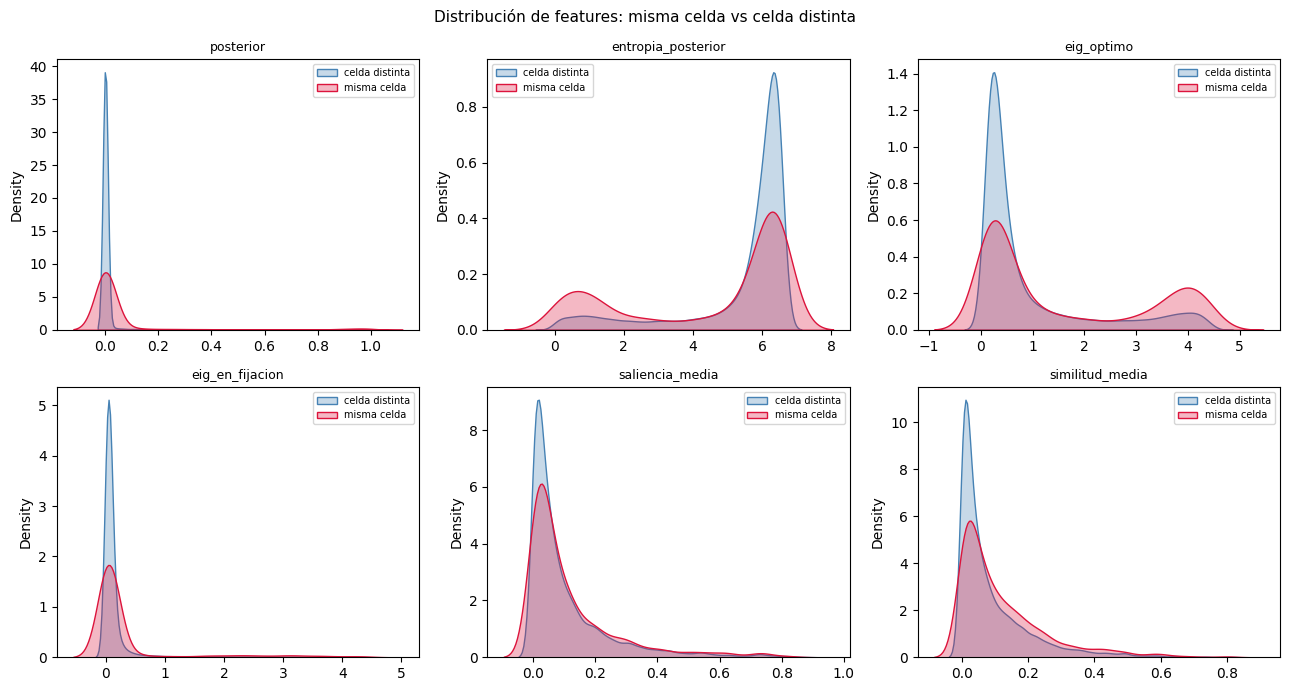

In [12]:
# Comparar features de grilla en fijaciones misma-celda vs fijaciones celda-distinta
feats_plot = [
    'posterior', 'entropia_posterior', 'eig_optimo', 'eig_en_fijacion',
    'saliencia_media', 'similitud_media',
]
feats_plot = [f for f in feats_plot if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, feats_plot):
    a = df[df['misma_celda']][feat].dropna()
    b = df[~df['misma_celda']][feat].dropna()
    sns.kdeplot(b, ax=ax, color='steelblue', label='celda distinta', fill=True, alpha=0.3)
    sns.kdeplot(a, ax=ax, color='crimson',   label='misma celda',    fill=True, alpha=0.3)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

for ax in axes.flat[len(feats_plot):]:
    ax.set_visible(False)

plt.suptitle('Distribución de features: misma celda vs celda distinta', fontsize=11)
plt.tight_layout()
plt.show()